In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [4]:
def roll_d4():
    return random.randint(1,4) 

In [5]:
def roll_d4_reroll_ones():
    val = roll_d4()
    if val == 1:
        return roll_d4()
    else:
        return val

In [6]:
def roll_d4_exploding():
    val = roll_d4_reroll_ones()
    if val == 4:
        return 4 + roll_d4_exploding()
    else:
        return val

In [7]:
def roll_crossbow():
    val = 0
    for i in range(3):
        val = val +roll_d4_exploding()
    return val

In [8]:
def apply_dr(damage, dr=5):
    return max(0, damage- dr)

In [9]:
def simulate_bolts():
    points = 82
    count = 0
    while points>0:
        points = points - apply_dr(roll_crossbow())
        count+=1
    return count
    

In [10]:
def average_finder(n):
    tot = 0
    for i in range(n):
        tot = tot+ simulate_bolts()
    return tot/n

In [11]:
print(average_finder(10000))

11.5885


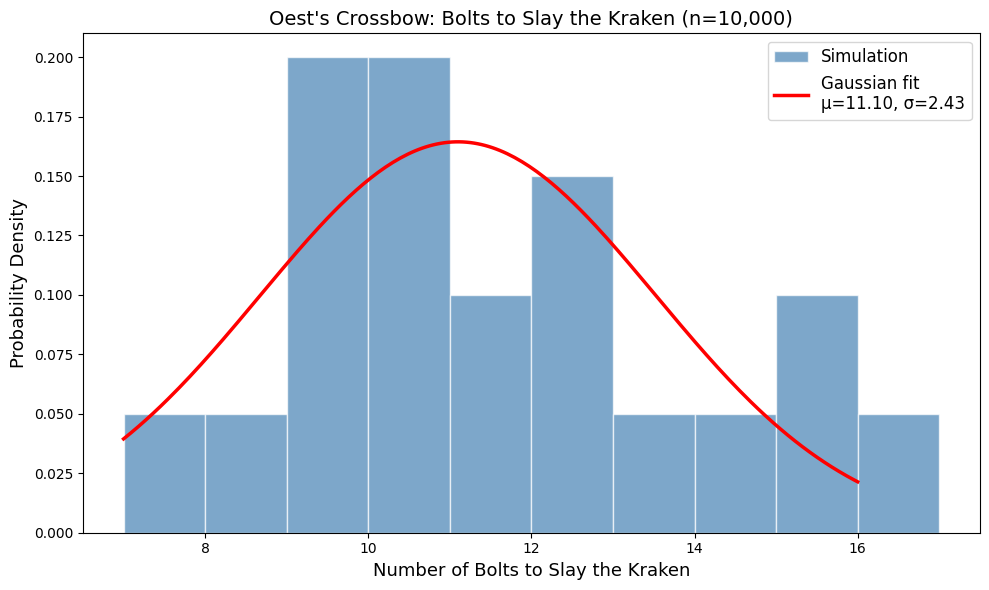

<Figure size 640x480 with 0 Axes>

Mean: 11.10, Std: 2.43


In [16]:
from io import BytesIO


n = 20
results = [simulate_bolts() for _ in range(n)]

# Gaussian fit
mu, std = np.mean(results), np.std(results)
x = np.linspace(min(results), max(results), 200)
gaussian = stats.norm.pdf(x, mu, std)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(results, bins=range(min(results), max(results)+2),
        density=True, color='steelblue', edgecolor='white', alpha=0.7, label='Simulation')
ax.plot(x, gaussian, 'r-', linewidth=2.5, label=f'Gaussian fit\nμ={mu:.2f}, σ={std:.2f}')
ax.set_xlabel('Number of Bolts to Slay the Kraken', fontsize=13)
ax.set_ylabel('Probability Density', fontsize=13)
ax.set_title("Oest's Crossbow: Bolts to Slay the Kraken (n=10,000)", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

buffer = BytesIO()
plt.savefig(buffer, format='png', dpi=150)
buffer.seek(0)
plt.savefig(buffer, format='png', dpi=150)
plt.show()

print(f"Mean: {mu:.2f}, Std: {std:.2f}")